In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as Optimizer
import matplotlib.pyplot as plt

In [18]:
n_sample=6000
batch_size=128
learning_rate=0.5
epochs=10
classes=6

X=torch.rand(n_sample,1,32,32)
y=torch.randint(0,classes,(n_sample,))




In [19]:
model=nn.Sequential(
    nn.Conv2d(in_channels=1,out_channels=16,padding=1,stride=1,kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(stride=2,kernel_size=2),
    
    nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(stride=2,kernel_size=2),

    nn.Flatten(),

    nn.Linear(32*8*8,6)

)

print(model)

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=2048, out_features=6, bias=True)
)


In [20]:
learning_rate=0.05
epochs=10
Loss_func=nn.CrossEntropyLoss()
optimizer=Optimizer.SGD(model.parameters(),lr=learning_rate)

Epoch 1/10, Loss = 84.4248
Epoch 2/10, Loss = 84.3116
Epoch 3/10, Loss = 84.2408
Epoch 4/10, Loss = 84.1932
Epoch 5/10, Loss = 84.1554
Epoch 6/10, Loss = 84.1225
Epoch 7/10, Loss = 84.0912
Epoch 8/10, Loss = 84.0611
Epoch 9/10, Loss = 84.0316
Epoch 10/10, Loss = 84.0017


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

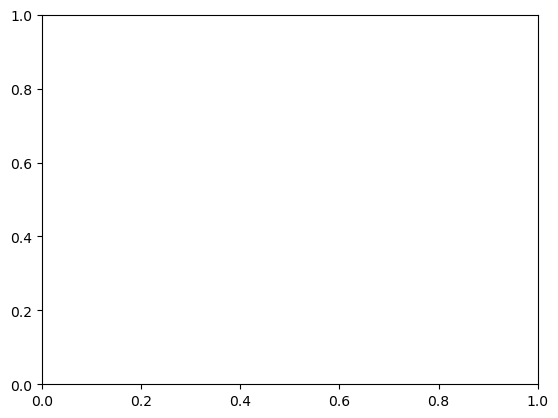

In [21]:
loss_history=[]
for epoch in range(epochs):
    total_loss=0
    for i in range(0,n_sample,batch_size):
        x_curr=X[i:i+batch_size]
        y_curr=y[i:i+batch_size]

        outputs=model(x_curr)
        loss=Loss_func(outputs,y_curr)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss+=loss
    print(f"Epoch {epoch+1}/{epochs}, Loss = {total_loss:.4f}")
    loss_history.append(total_loss)

plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()
    
    